In [19]:
import pandas as pd
import numpy as np

data = pd.read_csv(
    "data/Liver Patient Dataset (LPD)_train.csv",
    encoding="cp1252"
)

# Drop Gender column
data.drop('Gender of the patient', axis=1, inplace=True)



In [20]:
print(data.head())
print(data.info())
print(data.shape)

   Age of the patient  Total Bilirubin  Direct Bilirubin  \
0                65.0              0.7               0.1   
1                62.0             10.9               5.5   
2                62.0              7.3               4.1   
3                58.0              1.0               0.4   
4                72.0              3.9               2.0   

    Alkphos Alkaline Phosphotase   Sgpt Alamine Aminotransferase  \
0                          187.0                            16.0   
1                          699.0                            64.0   
2                          490.0                            60.0   
3                          182.0                            14.0   
4                          195.0                            27.0   

   Sgot Aspartate Aminotransferase  Total Protiens   ALB Albumin  \
0                             18.0             6.8           3.3   
1                            100.0             7.5           3.2   
2                         

In [21]:
print(data.columns.tolist())

['Age of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


In [22]:
# Check missing values
print(data.isnull().sum())
# Check zero values in each column
print((data == 0).sum())

Age of the patient                        2
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64
Age of the patient                      0
Total Bilirubin                         0
Direct Bilirubin                        0
 Alkphos Alkaline Phosphotase           0
 Sgpt Alamine Aminotransferase          0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
 ALB Albumin                            0
A/G Ratio Albumin and Globulin Ratio    0
Result                                  0
dtype: int64


In [23]:
# Remove duplicates values from the dataset
print("Before removing duplicates:", data.shape)
data = data.drop_duplicates()
print("After removing duplicates:", data.shape)

Before removing duplicates: (30691, 10)
After removing duplicates: (16564, 10)


In [24]:
import numpy as np
# Columns where 0 represents an invalid/missing measurement
columns = ['Age of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']

# Replace 0 with NaN
data[columns] = data[columns].replace(0, np.nan)

# Check missing values
print(data.isnull().sum())

Age of the patient                        1
Total Bilirubin                         530
Direct Bilirubin                        480
 Alkphos Alkaline Phosphotase           670
 Sgpt Alamine Aminotransferase          451
Sgot Aspartate Aminotransferase         384
Total Protiens                          357
 ALB Albumin                            398
A/G Ratio Albumin and Globulin Ratio    415
Result                                    0
dtype: int64


In [25]:
# Fill misssing values with median of each column
for column in columns:
    data[column] = data[column].fillna(data[column].median())

print(data.isnull().sum())

Age of the patient                      0
Total Bilirubin                         0
Direct Bilirubin                        0
 Alkphos Alkaline Phosphotase           0
 Sgpt Alamine Aminotransferase          0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
 ALB Albumin                            0
A/G Ratio Albumin and Globulin Ratio    0
Result                                  0
dtype: int64


In [26]:
# Verify the changes by checking the first 5 rows of the dataset again
print(data.head())

   Age of the patient  Total Bilirubin  Direct Bilirubin  \
0                65.0              0.7               0.1   
1                62.0             10.9               5.5   
2                62.0              7.3               4.1   
3                58.0              1.0               0.4   
4                72.0              3.9               2.0   

    Alkphos Alkaline Phosphotase   Sgpt Alamine Aminotransferase  \
0                          187.0                            16.0   
1                          699.0                            64.0   
2                          490.0                            60.0   
3                          182.0                            14.0   
4                          195.0                            27.0   

   Sgot Aspartate Aminotransferase  Total Protiens   ALB Albumin  \
0                             18.0             6.8           3.3   
1                            100.0             7.5           3.2   
2                         

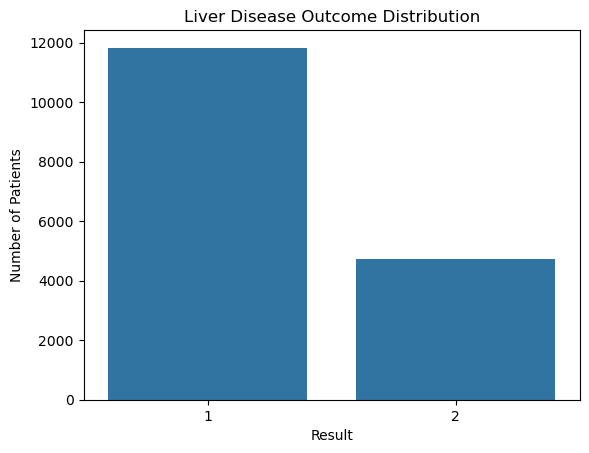

In [29]:
# Visualize the distribution of the target variable 'Result'

import matplotlib.pyplot as plt
import seaborn as sns

# Count of liver disease outcomes
sns.countplot(x='Result', data=data)

plt.title('Liver Disease Outcome Distribution')
plt.xlabel('Result')
plt.ylabel('Number of Patients')
plt.show()

In [30]:
# Separate features and target
X = data.drop('Result', axis=1)  # Take all columns except Result as input
y = data['Result']               # Take Result column as target

# Display the first 5 rows of features
print("Features:")
print(X.head())

# Display the first 5 rows of target
print("\nTarget:")
print(y.head())

Features:
   Age of the patient  Total Bilirubin  Direct Bilirubin  \
0                65.0              0.7               0.1   
1                62.0             10.9               5.5   
2                62.0              7.3               4.1   
3                58.0              1.0               0.4   
4                72.0              3.9               2.0   

    Alkphos Alkaline Phosphotase   Sgpt Alamine Aminotransferase  \
0                          187.0                            16.0   
1                          699.0                            64.0   
2                          490.0                            60.0   
3                          182.0                            14.0   
4                          195.0                            27.0   

   Sgot Aspartate Aminotransferase  Total Protiens   ALB Albumin  \
0                             18.0             6.8           3.3   
1                            100.0             7.5           3.2   
2               

In [31]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape) # (614, 8)
print("Testing data:", X_test.shape)

Training data: (13251, 9)
Testing data: (3313, 9)


In [32]:
# Create a new notebook cell:
from sklearn.linear_model import LogisticRegression

In [33]:
# Create a Logistic Regression model with a maximum of 1000 iterations to ensure convergence.
model = LogisticRegression(max_iter=1000)

In [34]:
# Train the model using the training data
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [35]:
# Make predictions on the testing set
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 ... 2 1 1]


In [36]:
from sklearn.metrics import accuracy_score
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

Accuracy: 0.7232115907032901
Accuracy in percentage: 72.32115907032902 %


In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate a confusion matrix to visualize the performance of the model
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2228  130]
 [ 787  168]]


In [41]:
# joblib is a library for efficiently serializing and deserializing Python objects, which is particularly useful for saving machine learning models. In this case, we will use joblib to save the trained Logistic Regression model to a file so that it can be loaded and used later without needing to retrain it.
import joblib

In [42]:
# Save the trained model to a file using joblib
joblib.dump(model, 'model/liver_model.pkl')
print("Model saved successfully!")

Model saved successfully!
